In [1]:
!pip install python-chess gymnasium stable-baselines3 sb3-contrib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 49.3 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 951.1/951.1 kB 26.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.4 MB/s eta 0:00:000:00:0100:01
  

In [2]:
import math, random
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import chess

# Trung tâm bàn cờ
CENTER_SQUARES = {chess.D4, chess.E4, chess.D5, chess.E5}

# Tiện ích
def seed_everything(seed: int = 42):
    random.seed(seed); np.random.seed(seed)

seed_everything(42)

In [3]:
def board_to_planes(board: chess.Board) -> np.ndarray:
    """
    Trả về tensor (8,8,12): 6 kênh cho trắng + 6 kênh cho đen theo thứ tự P,N,B,R,Q,K
    """
    planes = np.zeros((8, 8, 12), dtype=np.int8)
    # map piece_type -> channel offset
    type2idx = {chess.PAWN:0, chess.KNIGHT:1, chess.BISHOP:2, chess.ROOK:3, chess.QUEEN:4, chess.KING:5}
    for sq in chess.SQUARES:
        p = board.piece_at(sq)
        if not p: 
            continue
        r, c = divmod(sq, 8)
        base = 0 if p.color == chess.WHITE else 6
        planes[r, c, base + type2idx[p.piece_type]] = 1
    return planes

def legal_moves_mask(board: chess.Board) -> np.ndarray:
    """
    Trả về action mask 4096 (64*64), 1 nếu (from,to) hợp lệ.
    """
    mask = np.zeros(64*64, dtype=np.int8)
    for mv in board.legal_moves:
        idx = 64 * mv.from_square + mv.to_square
        mask[idx] = 1
    return mask

def decode_action_to_move(board: chess.Board, action_idx: int) -> chess.Move | None:
    """Chuyển chỉ số 0..4095 -> Move nếu hợp lệ, ngược lại None."""
    from_sq = action_idx // 64
    to_sq = action_idx % 64
    mv = chess.Move(from_sq, to_sq)
    return mv if mv in board.legal_moves else None

def count_legal_moves(board: chess.Board) -> int:
    return sum(1 for _ in board.legal_moves)

def center_control_count(board_after: chess.Board, color: bool) -> int:
    """Số ô trung tâm đang bị bên 'color' kiểm soát hoặc chiếm sau nước đi."""
    cnt = 0
    for sq in CENTER_SQUARES:
        if board_after.piece_at(sq) and board_after.piece_at(sq).color == color:
            cnt += 1
        if board_after.is_attacked_by(color, sq):
            cnt += 1
    return cnt


In [4]:
from dataclasses import dataclass

@dataclass
class RewardConfig:
    # Terminal
    win: float = 1.0
    loss: float = -1.0
    draw: float = 0.0

    # Length penalty (per ply) + cap per game
    c0: float = 5e-4
    c1: float = 2e-6
    length_cap: float = 0.08
    use_dynamic_endgame: bool = True     # thuộc tính #7

    # Material shaping: chọn 1 trong 2
    use_pbrs: bool = True                # bật PBRS (khuyến nghị)
    beta: float = 0.5
    gamma: float = 0.99
    # Nếu KHÔNG dùng PBRS, có thể bật capture nhỏ:
    use_capture_small: bool = False
    cap_p: float = 0.01
    cap_nb: float = 0.03
    cap_r: float = 0.05
    cap_q: float = 0.09

    # Center control (#4) & Mobility (#5)
    use_center: bool = True
    center_coef: float = 0.002
    use_mobility: bool = True
    mobility_coef: float = 0.01  # sẽ chia cho 100 trong reward

    # Repetition penalty (#6)
    use_repetition_penalty: bool = True
    repetition_penalty: float = 0.01

class RewardEngine:
    def __init__(self, cfg: RewardConfig):
        self.cfg = cfg
        self.length_acc = 0.0

    def reset(self):
        self.length_acc = 0.0

    # ---- material for PBRS ----
    @staticmethod
    def _material(board: chess.Board) -> float:
        vals = {chess.PAWN:1, chess.KNIGHT:3, chess.BISHOP:3, chess.ROOK:5, chess.QUEEN:9}
        s = 0.0
        for sq in chess.SQUARES:
            p = board.piece_at(sq)
            if not p: continue
            v = vals.get(p.piece_type, 0)
            s += v if p.color == chess.WHITE else -v
        return s

    def _phi(self, board: chess.Board) -> float:
        return self.cfg.beta * (self._material(board) / 39.0)

    # ---- step components ----
    def _length_penalty(self, ply: int) -> float:
        # dynamic endgame increase
        c0 = self.cfg.c0
        c1 = self.cfg.c1
        if self.cfg.use_dynamic_endgame:
            c0 = c0 * (1.0 + 0.5 * (ply / 100.0))
        step_pen = c0 + c1 * ply
        remaining = self.cfg.length_cap - self.length_acc
        if remaining <= 0:
            return 0.0
        pen = min(step_pen, remaining)
        self.length_acc += pen
        return -pen

    def _capture_small(self, board_before: chess.Board, mv: chess.Move) -> float:
        if not self.cfg.use_capture_small:
            return 0.0
        if not board_before.is_capture(mv): 
            return 0.0
        taken = board_before.piece_at(mv.to_square)
        if not taken or taken.piece_type == chess.KING:
            return 0.0
        if taken.piece_type == chess.PAWN:
            return self.cfg.cap_p
        if taken.piece_type in (chess.KNIGHT, chess.BISHOP):
            return self.cfg.cap_nb
        if taken.piece_type == chess.ROOK:
            return self.cfg.cap_r
        if taken.piece_type == chess.QUEEN:
            return self.cfg.cap_q
        return 0.0

    def step_reward(self, board_before: chess.Board, mv: chess.Move, board_after: chess.Board, last_player: bool) -> float:
        ply = (board_before.fullmove_number*2) - (0 if board_before.turn == chess.WHITE else 1)
        r = 0.0

        # length
        r += self._length_penalty(ply)

        # PBRS or capture
        if self.cfg.use_pbrs:
            r += (self.cfg.gamma * self._phi(board_after) - self._phi(board_before))
        else:
            r += self._capture_small(board_before, mv)

        # center control for the mover
        if self.cfg.use_center:
            # after move, it's opponent's turn; mover = not board_after.turn
            mover = not board_after.turn
            cc = center_control_count(board_after, mover)
            r += self.cfg.center_coef * cc

        # mobility: Δ legal moves for mover (approx)
        if self.cfg.use_mobility:
            # mobility after move for the next-to-move side isn't mover;
            # ta so sánh hợp lý: số legal của "mover" trước & sau
            mob_before = count_legal_moves(board_before)
            mob_after = count_legal_moves(board_after)
            delta = max(-100, min(100, mob_after - mob_before))
            r += self.cfg.mobility_coef * (delta / 100.0)

        # repetition penalty (áp ở step để sớm cắt hành vi lặp)
        if self.cfg.use_repetition_penalty:
            if board_after.is_repetition(3):
                r -= self.cfg.repetition_penalty

        return r

    def terminal_reward(self, board_after: chess.Board, last_mover_won: bool) -> float:
        if board_after.is_checkmate():
            return self.cfg.win if last_mover_won else self.cfg.loss
        if (board_after.is_stalemate() or board_after.is_insufficient_material() or
            board_after.is_seventyfive_moves() or board_after.is_fivefold_repetition() or
            board_after.can_claim_fifty_moves() or board_after.can_claim_threefold_repetition()):
            return self.cfg.draw
        return 0.0


In [5]:
class ChessEnv(gym.Env):
    """
    Action space: Discrete(4096) = 64(from)*64(to)
    Observation: (8,8,12) planes (int8 -> ta cast float32)
    """
    metadata = {"render_modes":[]}

    def __init__(self, reward_cfg: RewardConfig | None = None, illegal_action_mode: str = "penalize_and_random"):
        super().__init__()
        self.board = chess.Board()
        self.rew = RewardEngine(reward_cfg or RewardConfig())
        self.action_space = spaces.Discrete(64*64)
        self.observation_space = spaces.Box(low=0, high=1, shape=(8,8,12), dtype=np.int8)
        self.illegal_action_mode = illegal_action_mode  # "penalize_and_random" | "reject"

    # ---- helpers ----
    def _obs(self):
        return board_to_planes(self.board).astype(np.int8)

    def _mask(self):
        return legal_moves_mask(self.board)

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)
        self.board.reset()
        self.rew.reset()
        obs = self._obs()
        info = {"action_mask": self._mask()}
        return obs, info

    def step(self, action: int):
        info = {}

        # decode action
        mv = decode_action_to_move(self.board, action)

        # xử lý hành động không hợp lệ
        if mv is None:
            if self.illegal_action_mode == "reject":
                # không thay đổi trạng thái, phạt nhỏ
                obs = self._obs()
                info["action_mask"] = self._mask()
                return obs, -0.01, False, False, info
            # penalize and force a random legal move
            legal = list(self.board.legal_moves)
            if len(legal) == 0:
                # không có nước nào → ván sẽ kết thúc ở dưới
                pass
            else:
                mv = random.choice(legal)
            illegal_pen = -0.01
        else:
            illegal_pen = 0.0

        board_before = self.board.copy()
        last_player = self.board.turn  # True: white, False: black
        self.board.push(mv)
        board_after = self.board

        # terminal?
        terminated = False
        term_rew = 0.0
        if (board_after.is_checkmate() or board_after.is_stalemate() or
            board_after.is_insufficient_material() or board_after.is_seventyfive_moves() or
            board_after.is_fivefold_repetition() or board_after.can_claim_fifty_moves() or
            board_after.can_claim_threefold_repetition()):
            terminated = True
            last_mover_won = board_after.is_checkmate()  # chỉ khi checkmate thì last mover thắng
            term_rew = self.rew.terminal_reward(board_after, last_mover_won)

        # step reward
        step_rew = self.rew.step_reward(board_before, mv, board_after, last_player)

        reward = step_rew + term_rew + illegal_pen
        obs = self._obs()
        truncated = False  # có thể thêm giới hạn ply nếu muốn
        info["action_mask"] = self._mask()
        return obs, float(reward), terminated, truncated, info


In [6]:
env = ChessEnv()
obs, info = env.reset(seed=123)
print("Obs shape:", obs.shape, "Num legal:", info["action_mask"].sum())

total = 0.0
for t in range(50):
    mask = info["action_mask"]
    legal_actions = np.where(mask == 1)[0]
    a = int(np.random.choice(legal_actions))  # random hợp lệ
    obs, r, term, trunc, info = env.step(a)
    total += r
    if term or trunc:
        print(f"Terminated at t={t}, total reward={total:.4f}")
        break
print("Done. Current board:\n", env.board)


Obs shape: (8, 8, 12) Num legal: 20
Done. Current board:
 . . q r k . . r
p . p . . . . p
n . . b . . . .
. . . . p p P .
. P . . . . P .
p . p P n . K R
. . R Q P . P .
. . N . . B N .


# Thuật toán PPO

In [7]:
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class ChessCNN(BaseFeaturesExtractor):
    """
    Input: (C,H,W) = (12, 8, 8) — ta sẽ permute từ (8,8,12)
    """
    def __init__(self, observation_space, features_dim: int = 256):
        # gọi super với features_dim tạm, sẽ set ở cuối
        super().__init__(observation_space, features_dim=1)
        in_channels = 12
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten(),
        )
        # tính kích thước phẳng
        with th.no_grad():
            sample = th.zeros((1, in_channels, 8, 8))
            n_flat = self.net(sample).shape[1]
        self.linear = nn.Sequential(
            nn.Linear(n_flat, 512), nn.ReLU(),
            nn.Linear(512, features_dim), nn.ReLU(),
        )
        self._features_dim = features_dim

    def forward(self, obs: th.Tensor) -> th.Tensor:
        # env trả (8,8,12) int8 → policy nhận float32; permute sang (N,12,8,8)
        x = obs.float().permute(0, 3, 1, 2)
        x = self.net(x)
        x = self.linear(x)
        return x


2025-10-22 03:50:40.562764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761105040.733695      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761105040.790048      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor
from stable_baselines3.common.callbacks import BaseCallback

N_ENVS = 4

def action_mask_fn(env: ChessEnv):
    return env._mask()

def make_env(seed=0):
    def _thunk():
        env = ChessEnv()
        env = ActionMasker(env, action_mask_fn)
        return env
    return _thunk

vec_env = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])
vec_env = VecMonitor(vec_env)


2025-10-22 03:51:36.688559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-22 03:51:36.688768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-22 03:51:36.717533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-22 03:51:36.721533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761105096.727423     115 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

In [10]:
import os, numpy as np
from pathlib import Path
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.callbacks import BaseCallback

LOG_DIR = Path("./tb_chess"); LOG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR = Path("./models"); MODEL_DIR.mkdir(exist_ok=True, parents=True)

class KLStopCallback(BaseCallback):
    """
    Nếu KL quá cao → dừng sớm (bảo vệ PPO).
    """
    def __init__(self, kl_threshold=0.04, verbose=0):
        super().__init__(verbose)
        self.kl_threshold = kl_threshold

    def _on_step(self) -> bool:
        # SB3 không xuất KL trực tiếp; ta ước lượng qua info dict nếu có
        # Ở đây ta không có, nên bỏ qua. Giữ chỗ để sau này cắm nếu cần.
        return True

stop_no_improve = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=10, min_evals=20, verbose=1
)

# Eval self-play nhanh (1 env) — dùng mean reward để chọn best
eval_env = DummyVecEnv([make_env(123)])
eval_env = VecMonitor(eval_env, filename=None)
eval_cb = EvalCallback(
    eval_env, best_model_save_path=str(MODEL_DIR),
    n_eval_episodes=20, eval_freq=5000, deterministic=False,
    render=False, callback_after_eval=stop_no_improve
)


In [12]:
import torch, os
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True              # tăng tốc conv
    torch.set_float32_matmul_precision("high")         # PyTorch 2.x
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
DEVICE


PyTorch: 2.6.0+cu124
CUDA available: True
CUDA device: Tesla T4


'cuda'

In [13]:
policy_kwargs = dict(
    features_extractor_class=ChessCNN,
    features_extractor_kwargs=dict(features_dim=256),
    net_arch=dict(pi=[256,128], vf=[256,128]),
)

model = MaskablePPO(
    policy=MaskableActorCriticPolicy,
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048//N_ENVS,     # giữ tổng rollout ~2048
    batch_size=1024,          # tăng batch giảm nhiễu, hợp với GPU
    n_epochs=6,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.005,
    vf_coef=0.5,
    tensorboard_log="./tb_chess",
    policy_kwargs=policy_kwargs,
    verbose=1,
    device="cuda" if DEVICE=="cuda" else "cpu",
)
model

Using cuda device


In [14]:
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.vec_env import DummyVecEnv

# Eval env (đồng cấu hình mask)
eval_env = DummyVecEnv([make_env(123)])
eval_env = VecMonitor(eval_env)

stop_no_improve = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=10, min_evals=20, verbose=1
)

eval_cb = EvalCallback(
    eval_env,
    best_model_save_path="./models",
    log_path="./tb_chess/eval_logs",
    n_eval_episodes=20,
    eval_freq=5000,
    deterministic=False,
    callback_after_eval=stop_no_improve
)

TIMESTEPS = 100_000  # bạn có thể tăng lên 500k–2M sau khi thấy xu hướng tốt
model.learn(total_timesteps=TIMESTEPS, callback=[eval_cb])
model.save(f"./models/ppo_chess_{TIMESTEPS//1000}k.zip")
print("Saved model.")


Logging to ./tb_chess/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 234      |
|    ep_rew_mean     | 1.48     |
| time/              |          |
|    fps             | 542      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 286           |
|    ep_rew_mean          | 1.52          |
| time/                   |               |
|    fps                  | 497           |
|    iterations           | 2             |
|    time_elapsed         | 8             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00035255976 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -3.07         |
|    explained_v

In [31]:
import numpy as np
import chess

# Đối thủ random: luôn chọn 1 action hợp lệ từ action mask 4096
class RandomLegalOpponent:
    def select(self, env):
        mask = env._mask()  # vector 4096
        legal = np.flatnonzero(mask == 1)
        if legal.size == 0:
            return 0  # fallback an toàn (sẽ bị env xử lý)
        return int(np.random.choice(legal))

def _game_result_for_agent(board: chess.Board, agent_moved_last: bool) -> int:
    """
    Trả về: +1 nếu agent thắng, 0 hòa, -1 thua.
    Dựa trên trạng thái cuối cùng của bàn cờ và việc agent có đi nước cuối hay không.
    """
    if board.is_checkmate():
        # Người vừa đi là bên thắng
        return 1 if agent_moved_last else -1
    if (board.is_stalemate() or board.is_insufficient_material() or
        board.is_seventyfive_moves() or board.is_fivefold_repetition() or
        board.can_claim_fifty_moves() or board.can_claim_threefold_repetition()):
        return 0
    # Không nên xảy ra (vì vòng chơi dừng ở terminal/truncate), coi như hòa
    return 0

def play_one_game(agent, *, as_white: bool = True, max_moves: int = 300,
                  deterministic: bool = False, reward_cfg=None, seed: int | None = None):
    """
    Chơi 1 ván với đối thủ random.
    - agent: model MaskablePPO đã load
    - as_white: agent cầm trắng hay đen
    - max_moves: giới hạn số nước (ply) để tránh ván quá dài
    - deterministic: dùng policy greedy khi predict
    - reward_cfg: RewardConfig để tạo env giống lúc train (nếu cần)
    - seed: đặt seed cho env.reset()
    Trả về: (res, total_reward, ply)
      res ∈ {+1, 0, -1}, total_reward là tổng reward step-wise, ply = số nước đã đi
    """
    # Tạo env mới mỗi ván (dùng cùng cấu hình reward nếu bạn có)
    env = ChessEnv(reward_cfg) if reward_cfg is not None else ChessEnv()
    obs, info = env.reset(seed=seed)
    opp = RandomLegalOpponent()

    total_r = 0.0
    agent_moved_last = False

    for _ in range(max_moves):
        # Lượt của agent?
        agents_turn = (env.board.turn and as_white) or ((not env.board.turn) and (not as_white))

        if agents_turn:
            mask = info.get("action_mask", env._mask())
            action, _ = agent.predict(obs, action_masks=mask, deterministic=deterministic)
            agent_moved_last = True
        else:
            action = opp.select(env)
            agent_moved_last = False

        obs, r, term, trunc, info = env.step(int(action))
        total_r += float(r)

        if term or trunc:
            break

    # Kết quả cuối
    res = _game_result_for_agent(env.board, agent_moved_last)
    ply = len(env.board.move_stack)
    return res, total_r, ply

def evaluate_vs_random(agent, n_games: int = 50, max_moves: int = 300,
                       deterministic: bool = False, reward_cfg=None, seed: int | None = 123):
    """
    Chạy n_games (luân phiên trắng/đen) và in thống kê W/D/L + median ply.
    """
    rng = np.random.RandomState(seed if seed is not None else 123)
    wins = draws = losses = 0
    lengths = []
    totals = []

    for i in range(n_games):
        as_white = (i % 2 == 0)
        # mỗi game có thể đặt seed khác nhau nếu muốn reproducible
        game_seed = None if seed is None else int(rng.randint(0, 10**6))
        res, total_r, ply = play_one_game(
            agent,
            as_white=as_white,
            max_moves=max_moves,
            deterministic=deterministic,
            reward_cfg=reward_cfg,
            seed=game_seed
        )
        if res == 1: wins += 1
        elif res == 0: draws += 1
        else: losses += 1
        lengths.append(ply)
        totals.append(total_r)

    print(f"W/D/L vs random: {wins}/{draws}/{losses} (n={n_games})")
    print(f"Median ply: {np.median(lengths)} | Mean ply: {np.mean(lengths):.1f}")
    print(f"Avg total reward: {np.mean(totals):.3f} ± {np.std(totals):.3f}")
    return dict(wins=wins, draws=draws, losses=losses,
                median_ply=float(np.median(lengths)),
                mean_ply=float(np.mean(lengths)),
                avg_total_reward=float(np.mean(totals)))


In [33]:
# Nếu bạn có best_model.zip:
# agent = MaskablePPO.load("./models/best_model.zip", env=venv, device="auto")
# Nếu không, dùng model hiện tại:
agent = model

# Đánh giá 50 ván, luân phiên trắng/đen:
metrics = evaluate_vs_random(agent, n_games=50, max_moves=300, deterministic=False)


W/D/L vs random: 2/43/5 (n=50)
Median ply: 300.0 | Mean ply: 259.1
Avg total reward: 1.736 ± 0.392


In [35]:
from sb3_contrib import MaskablePPO

MODEL_PATH = "./models/best_model.zip"   # đổi nếu bạn lưu tên khác
agent = MaskablePPO.load(MODEL_PATH, device="auto")
print("Loaded:", MODEL_PATH)


Loaded: ./models/best_model.zip


In [36]:
import chess, chess.pgn, numpy as np
from datetime import datetime

def result_for_agent(board: chess.Board, agent_moved_last: bool) -> int:
    if board.is_checkmate():
        return 1 if agent_moved_last else -1
    if (board.is_stalemate() or board.is_insufficient_material() or
        board.is_seventyfive_moves() or board.is_fivefold_repetition() or
        board.can_claim_fifty_moves() or board.can_claim_threefold_repetition()):
        return 0
    return 0

def save_pgn(move_stack, result_str="*",
             out_path=f"./game_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pgn"):
    game = chess.pgn.Game()
    game.headers["Event"] = "RL-ChessAI Demo"
    game.headers["Result"] = result_str
    node = game
    board = chess.Board()
    for mv in move_stack:
        node = node.add_variation(mv)
        board.push(mv)
    with open(out_path, "w", encoding="utf-8") as f:
        print(game, file=f)
    print("Saved PGN →", out_path)


In [37]:
import numpy as np

class RandomLegalOpponent:
    def select(self, env):
        mask = env._mask()
        legal = np.flatnonzero(mask == 1)
        return int(np.random.choice(legal)) if legal.size else 0

def play_agent_vs_random(agent, *, as_white=True, max_moves=300,
                         deterministic=False, reward_cfg=None, show_board=True, save_game=True):
    env = ChessEnv(reward_cfg) if reward_cfg is not None else ChessEnv()
    obs, info = env.reset()
    opp = RandomLegalOpponent()

    total_r = 0.0
    agent_moved_last = False

    if show_board:
        print(env.board.unicode())

    for ply in range(max_moves):
        agents_turn = (env.board.turn and as_white) or ((not env.board.turn) and (not as_white))
        if agents_turn:
            mask = info.get("action_mask", env._mask())
            action, _ = agent.predict(obs, action_masks=mask, deterministic=deterministic)
            # Lấy SAN TRƯỚC khi push
            mv_idx = int(action)
            mv = chess.Move(mv_idx // 64, mv_idx % 64)
            if mv not in env.board.legal_moves:
                # fallback (hiếm khi xảy ra với MaskablePPO)
                legal = np.flatnonzero(mask == 1)
                mv = chess.Move(legal[0]//64, legal[0]%64)
            move_san = env.board.san(mv)
            agent_moved_last = True
        else:
            action = opp.select(env)
            mv = chess.Move(action // 64, action % 64)
            move_san = env.board.san(mv)
            agent_moved_last = False

        obs, r, term, trunc, info = env.step(int(action))
        total_r += float(r)

        if show_board:
            who = "Trắng" if not env.board.turn else "Đen"  # bên vừa đi
            print(f"\nPly {ply+1}: {who} đi {move_san}")
            print(env.board.unicode())

        if term or trunc:
            break

    # Kết quả
    res = result_for_agent(env.board, agent_moved_last)
    res_str = "1-0" if res==1 else "0-1" if res==-1 else "1/2-1/2"
    print("\nKết quả:", res_str, "| Tổng reward:", round(total_r, 4), "| Ply:", len(env.board.move_stack))

    if save_game:
        save_pgn(env.board.move_stack, result_str=res_str)

    return res, total_r, len(env.board.move_stack)

# Chạy thử: agent cầm Trắng, đối thủ Random
_ = play_agent_vs_random(agent, as_white=True, deterministic=False, max_moves=200, show_board=False)



Kết quả: 1/2-1/2 | Tổng reward: 1.2166 | Ply: 200
Saved PGN → ./game_20251022_041446.pgn


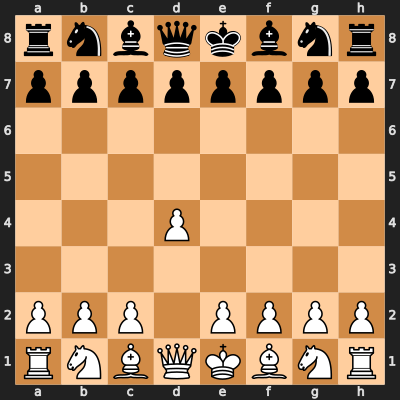

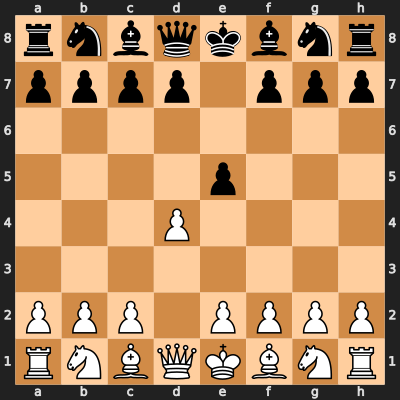

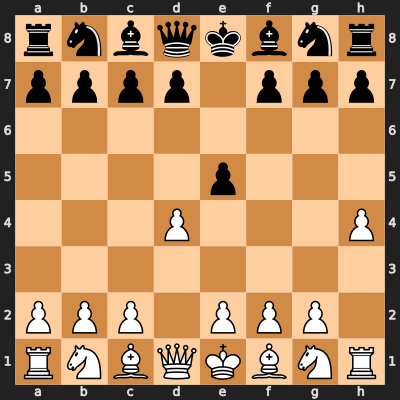

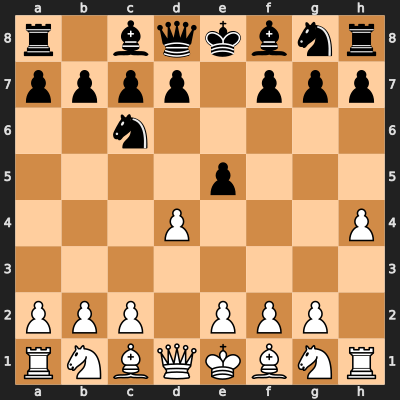

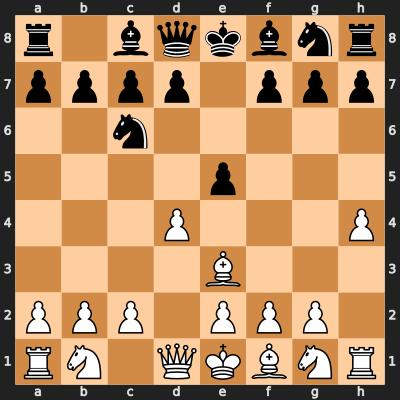

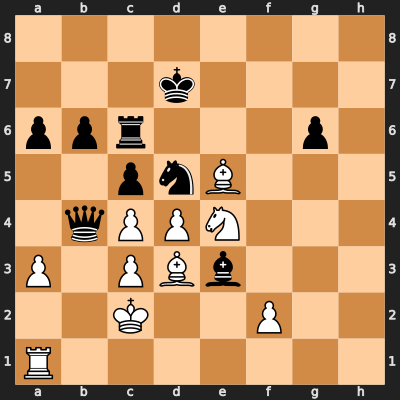

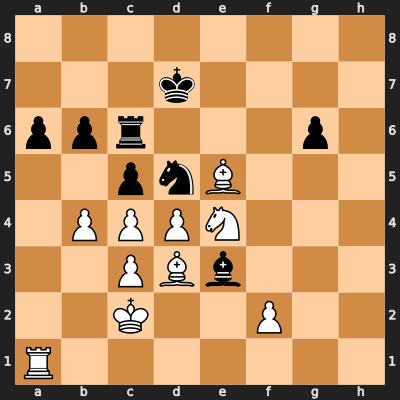

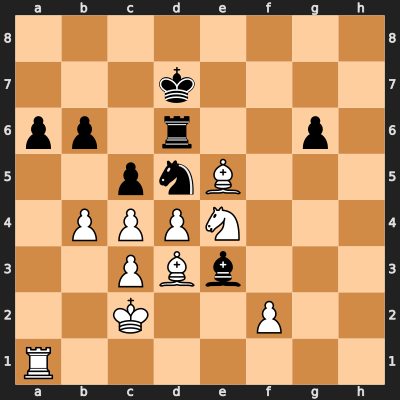

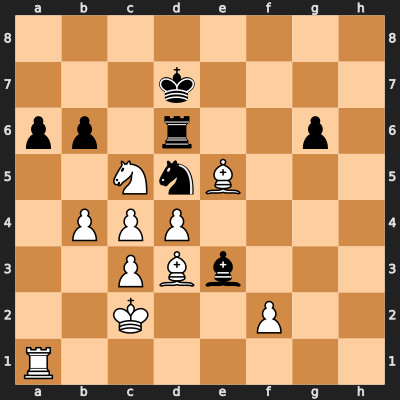

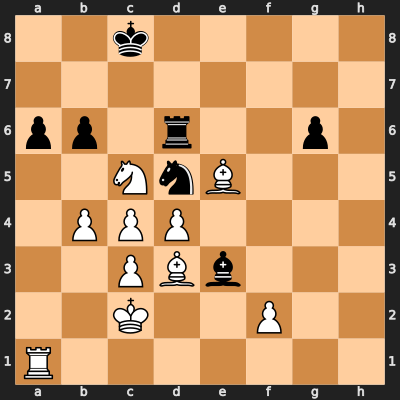

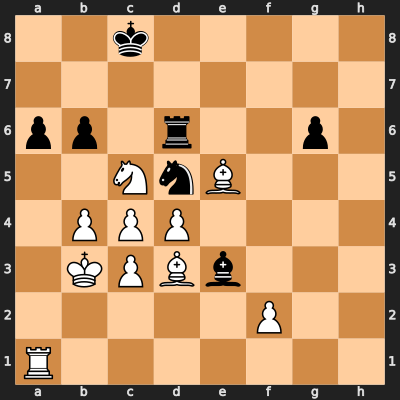

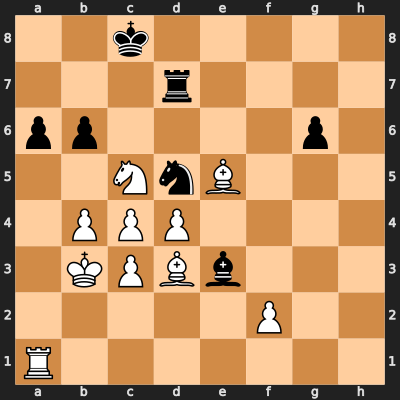

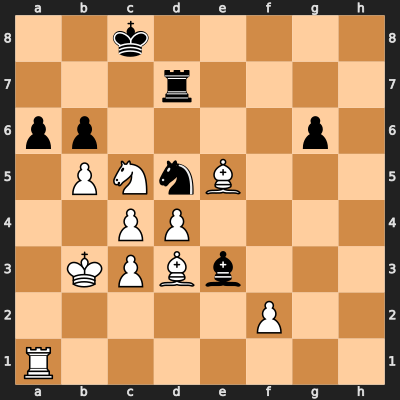

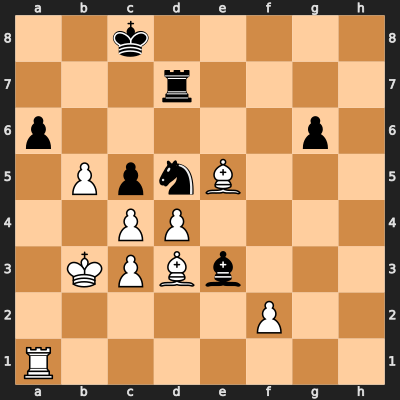

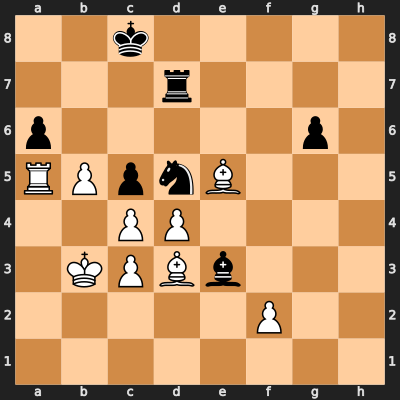

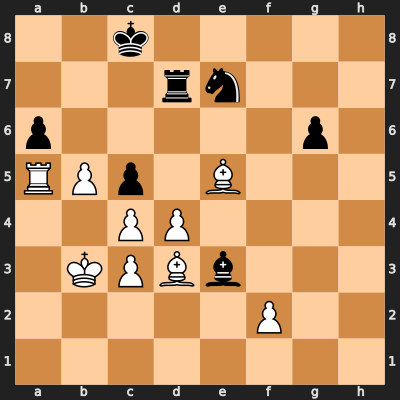

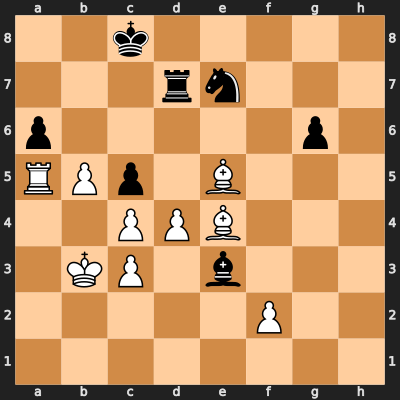

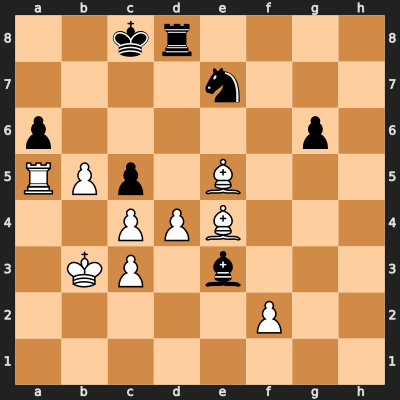

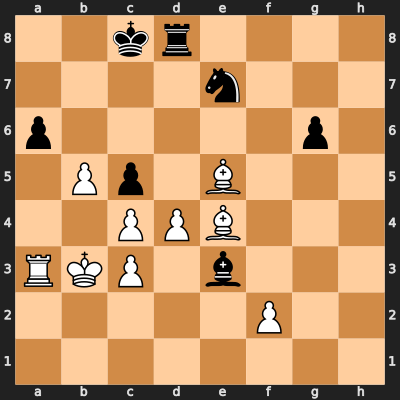

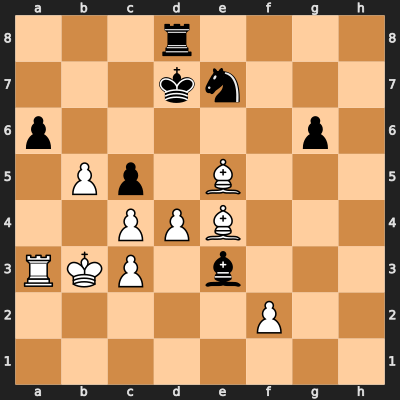

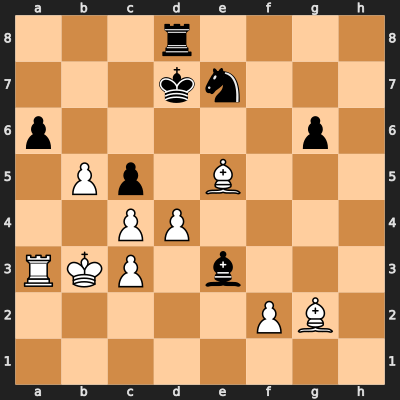

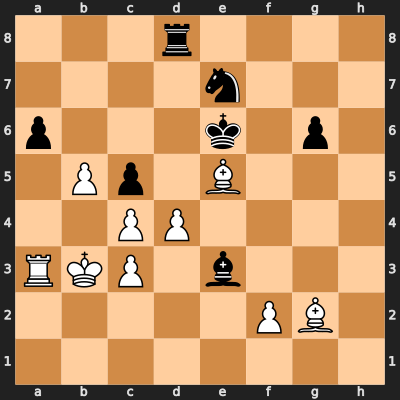

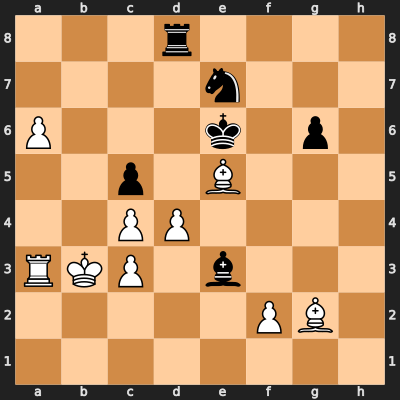

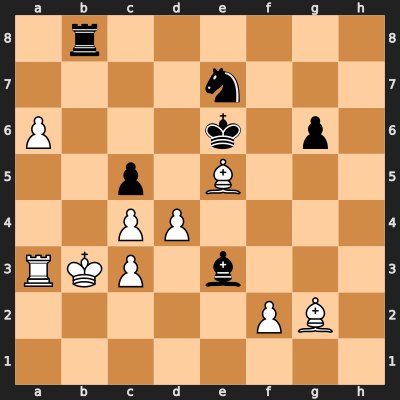

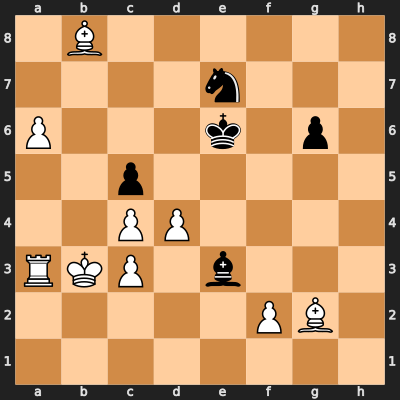

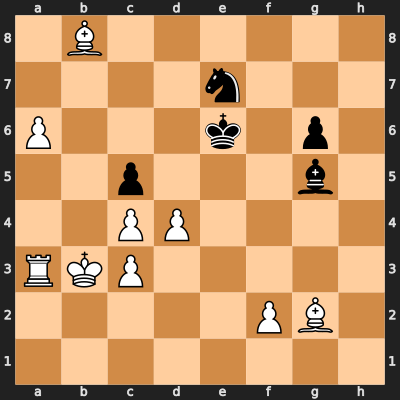

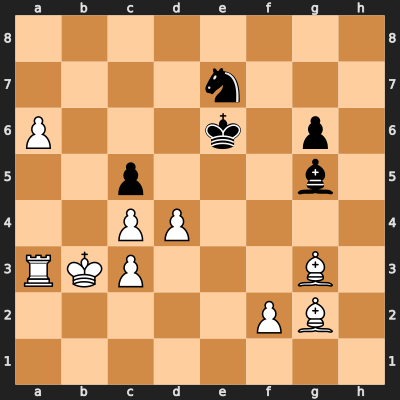

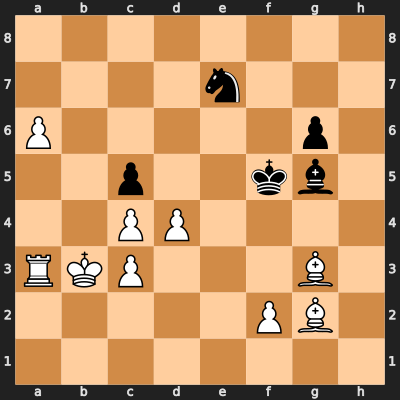

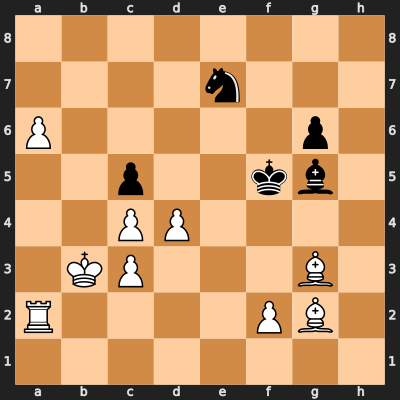

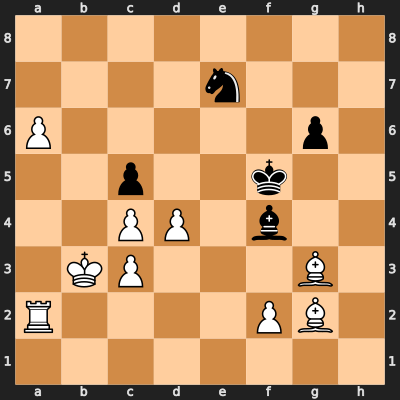

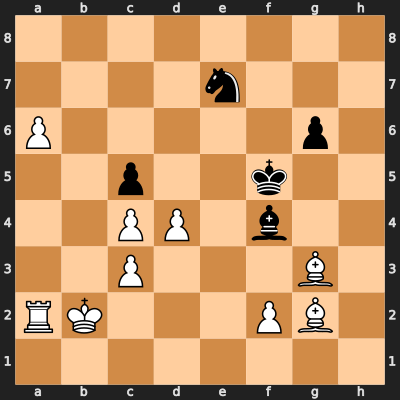

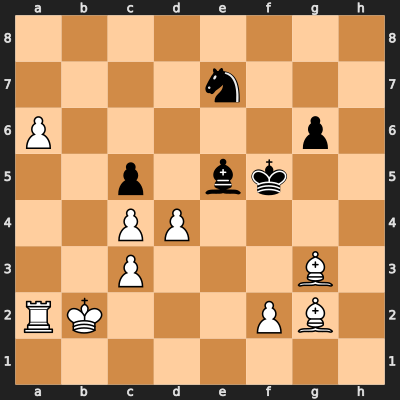

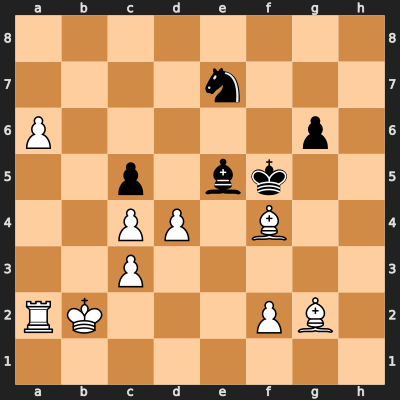

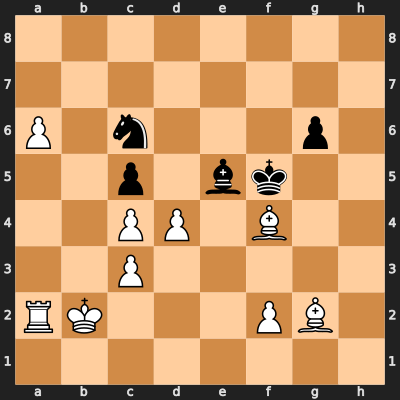

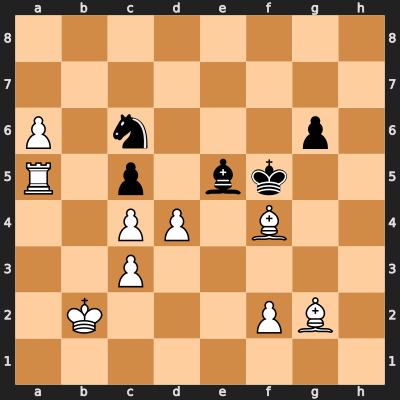

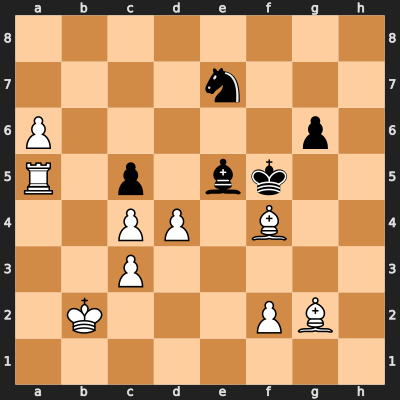

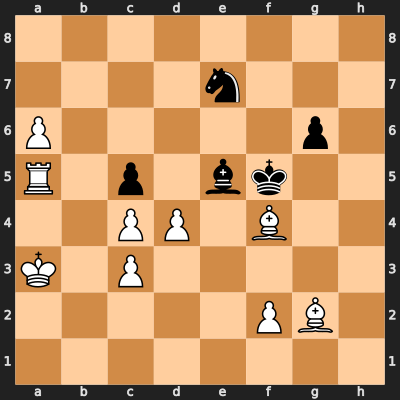

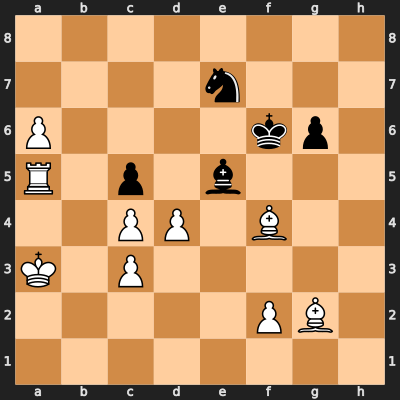

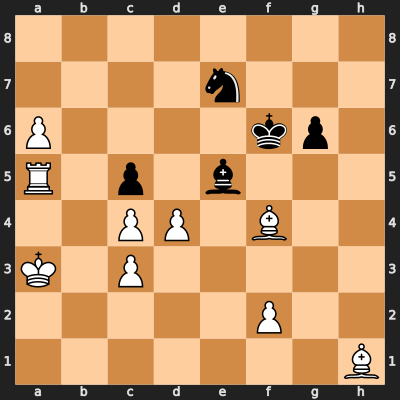

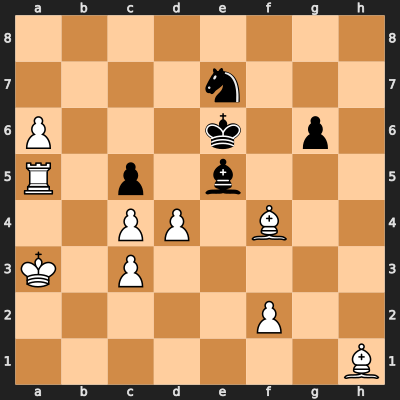

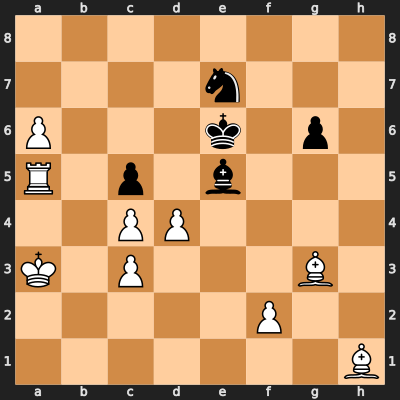

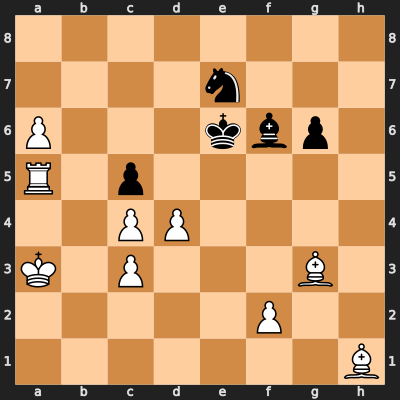

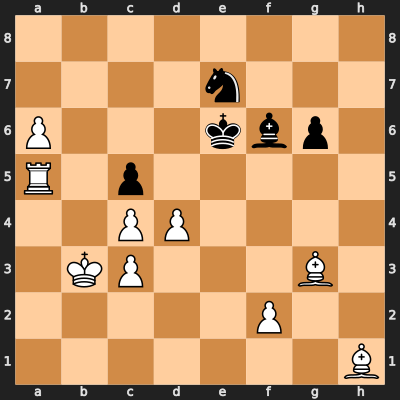

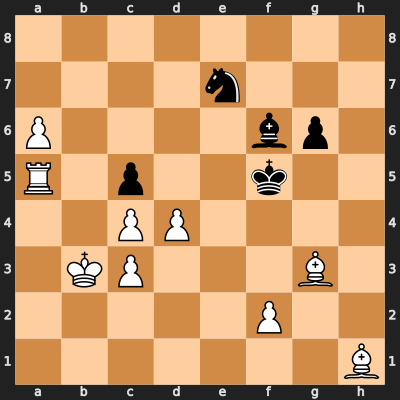

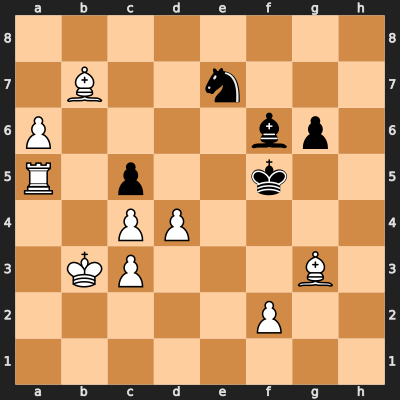

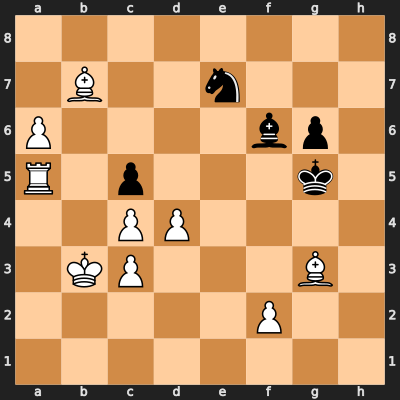

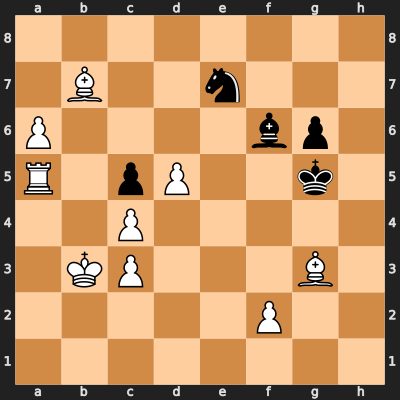

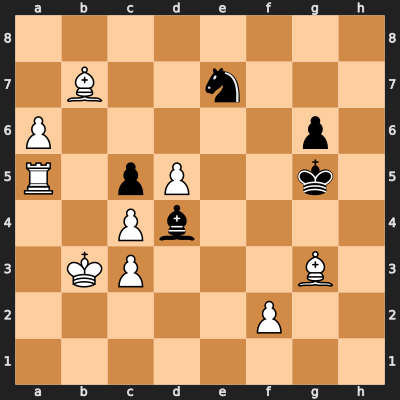

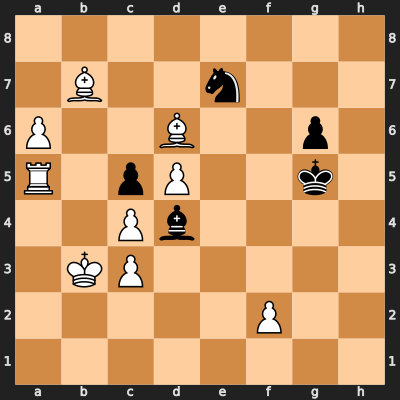

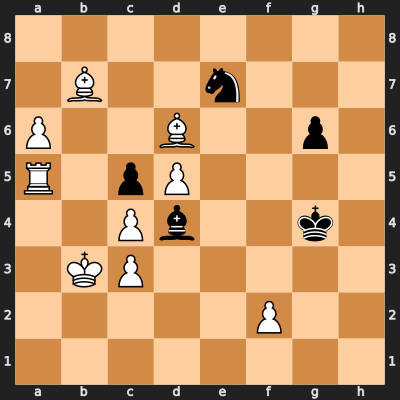

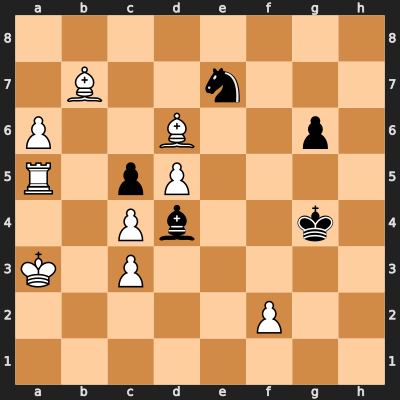

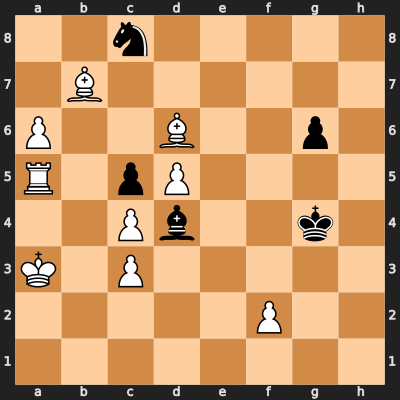

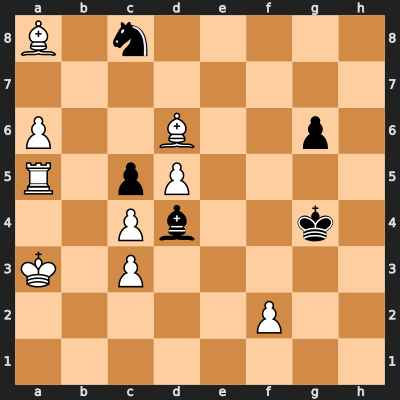

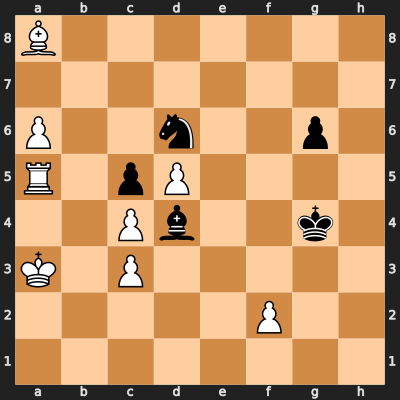

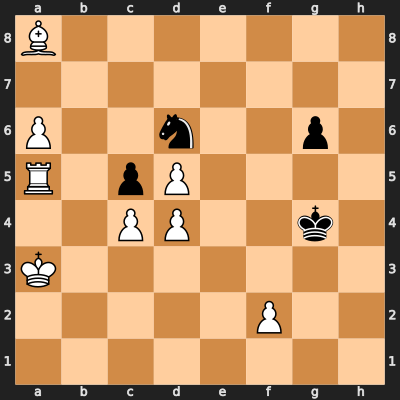

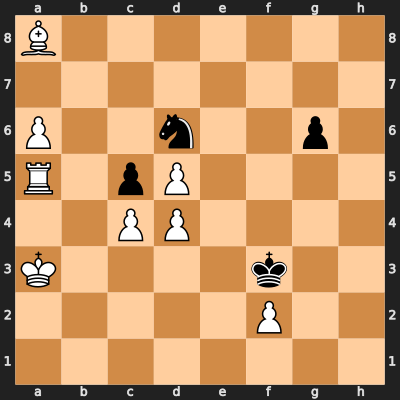

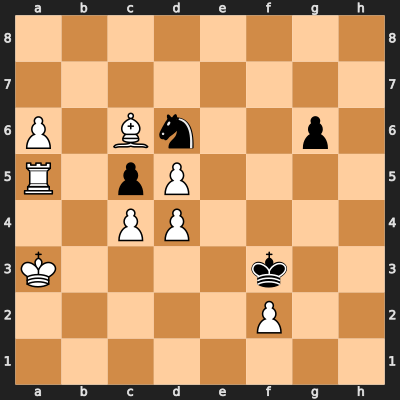

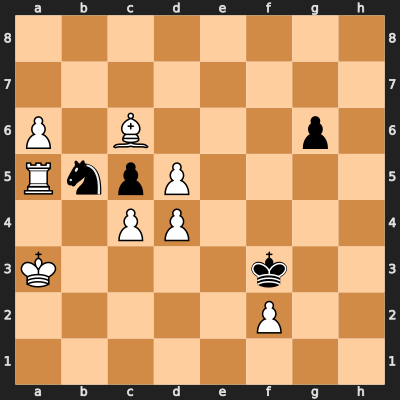

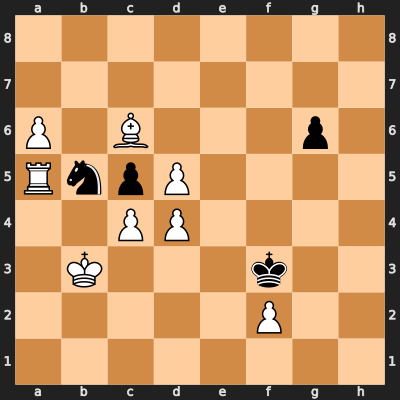

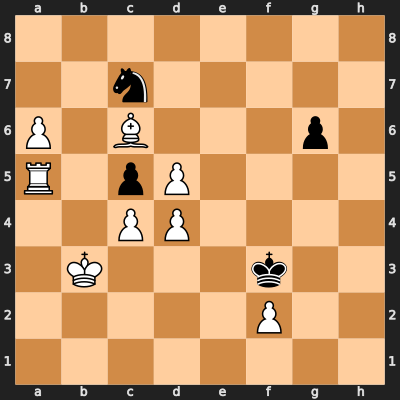

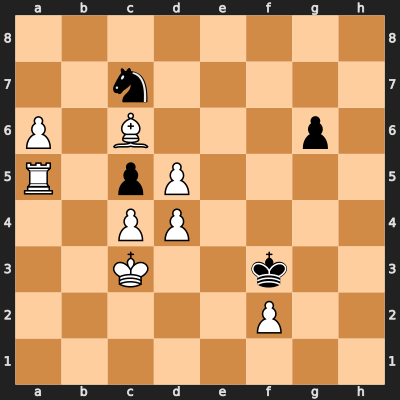

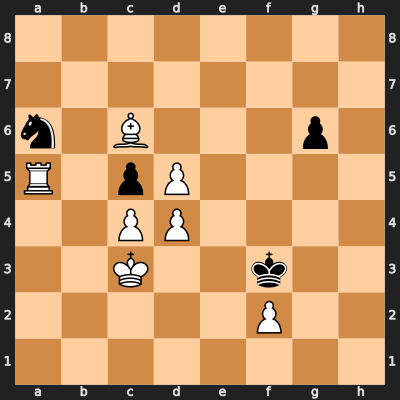

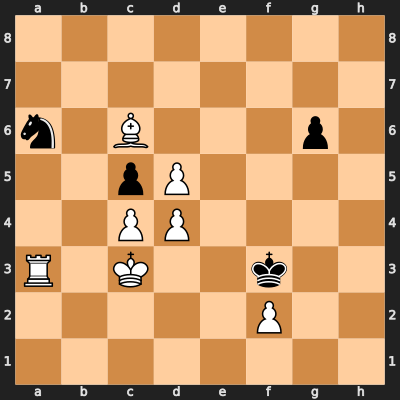

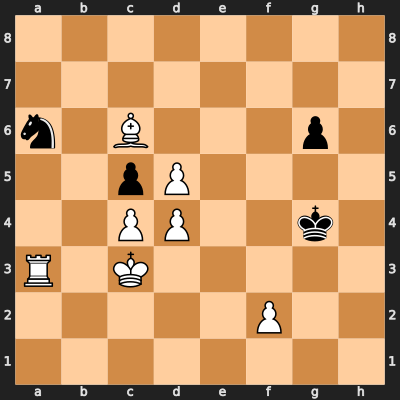

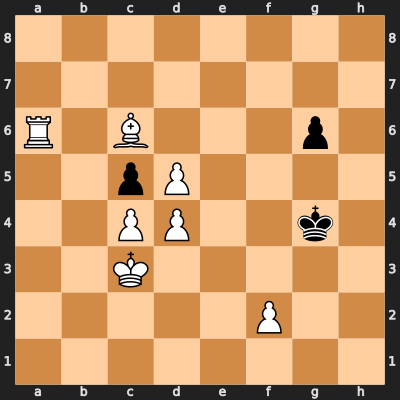

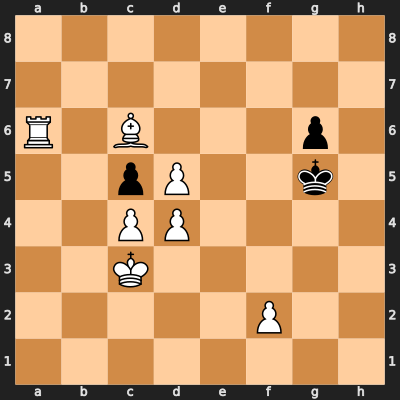

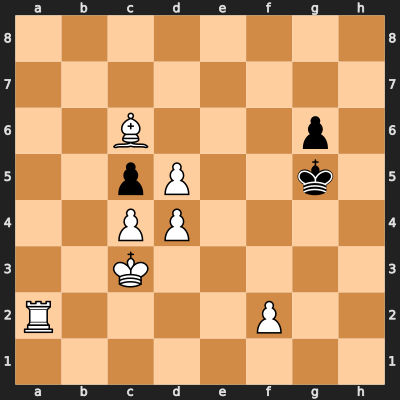

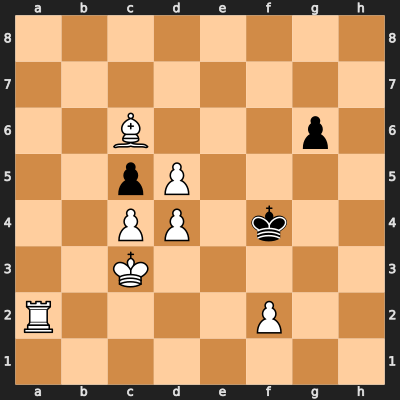

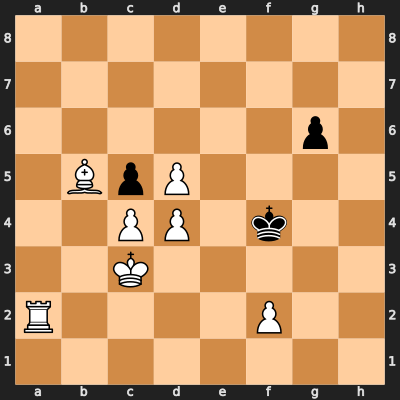

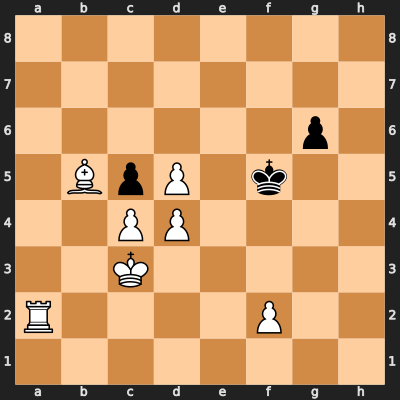

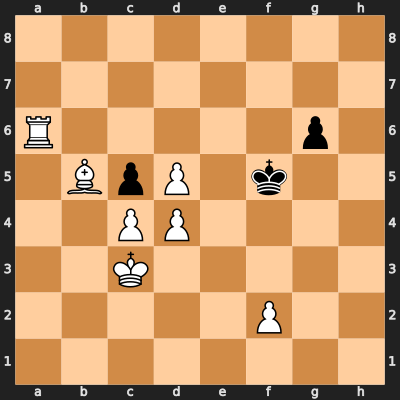

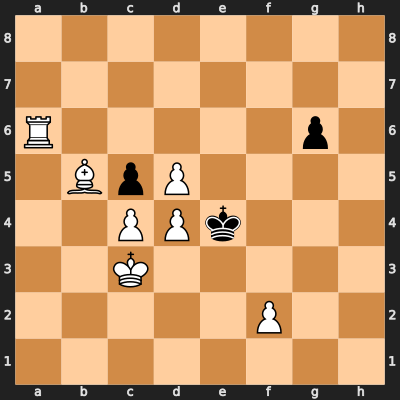

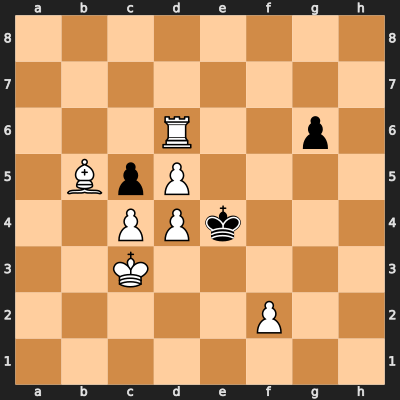

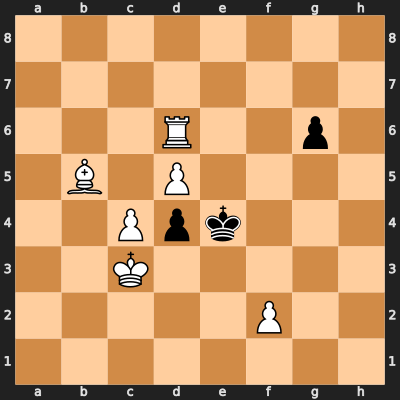

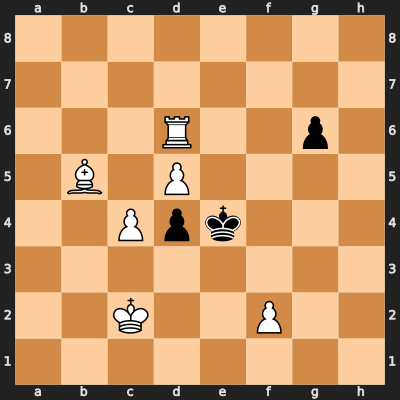

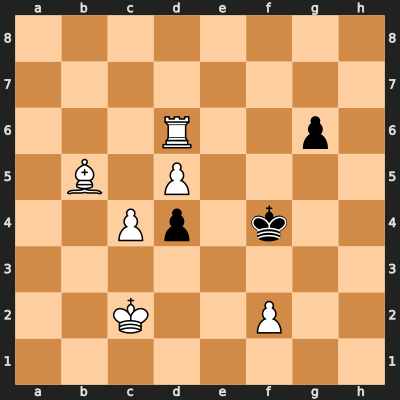

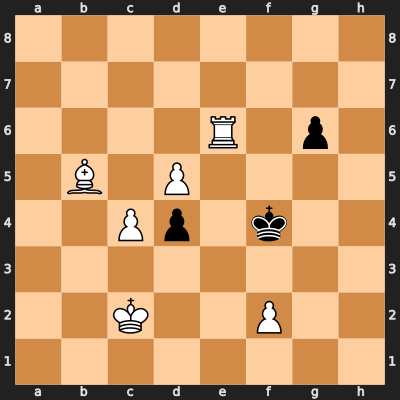

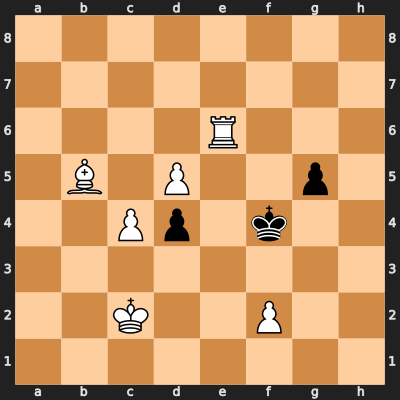

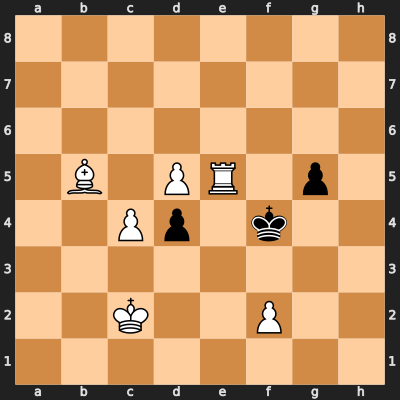

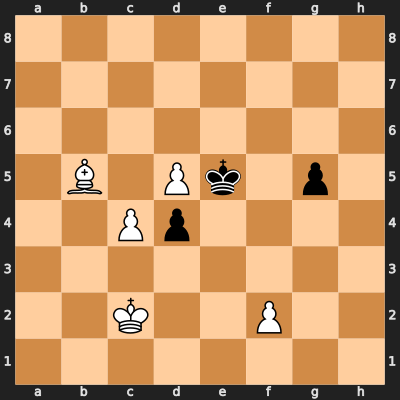

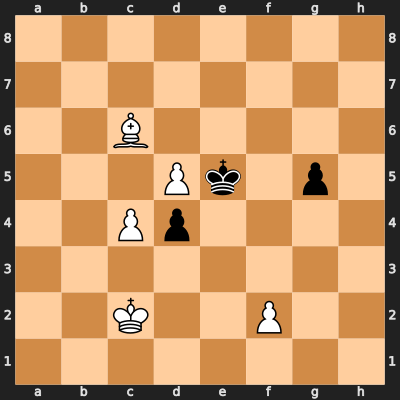

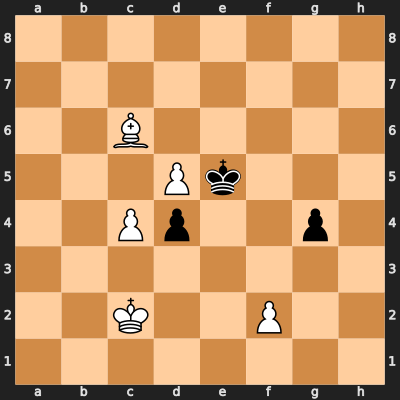

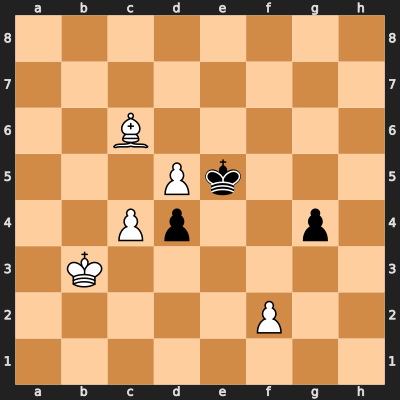

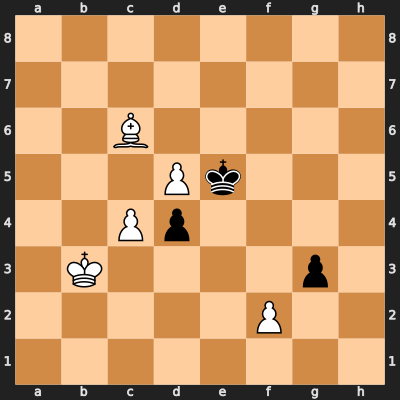

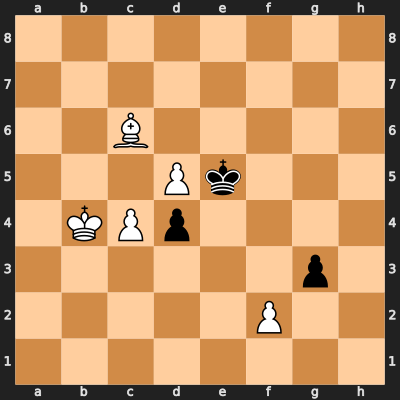

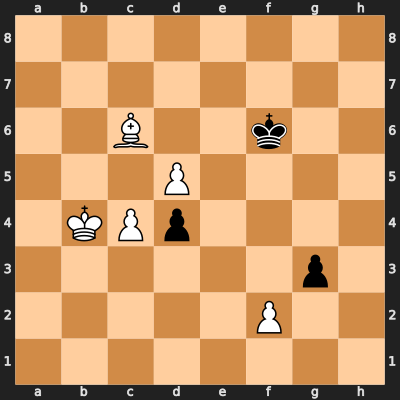

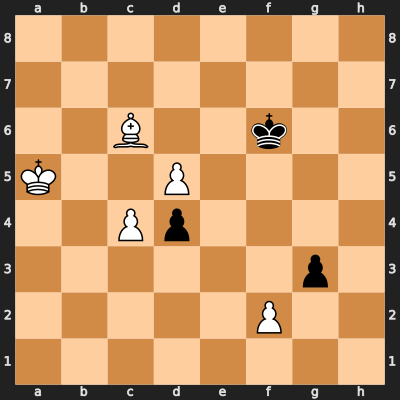

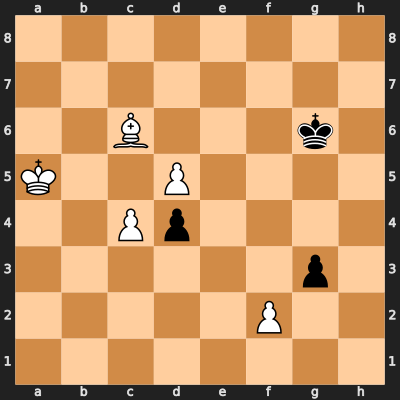

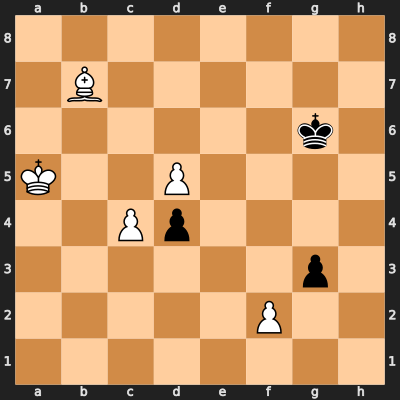

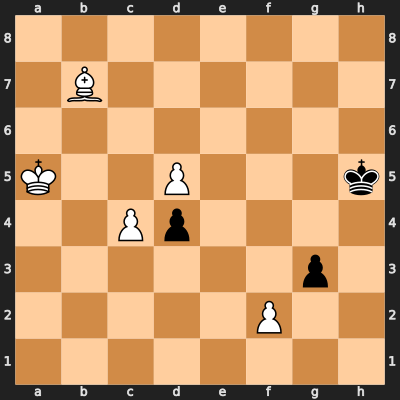

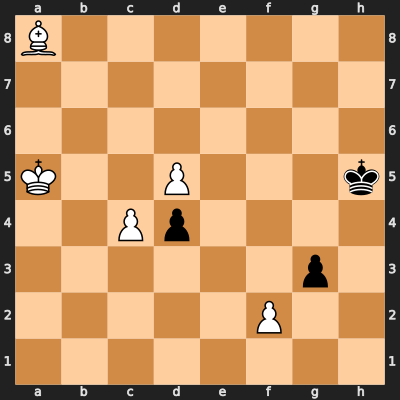

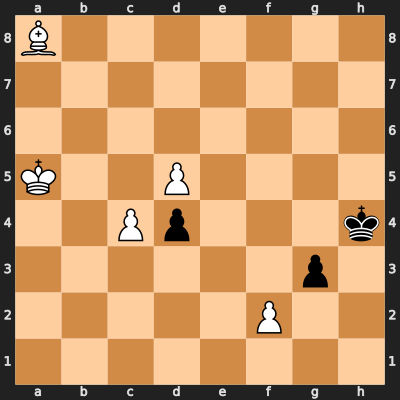

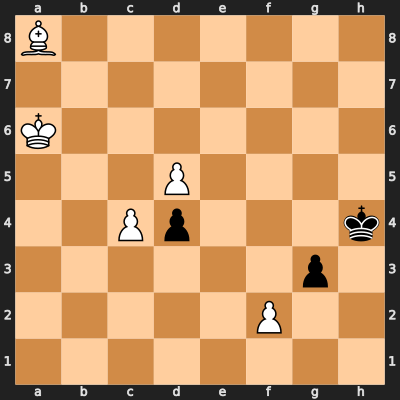

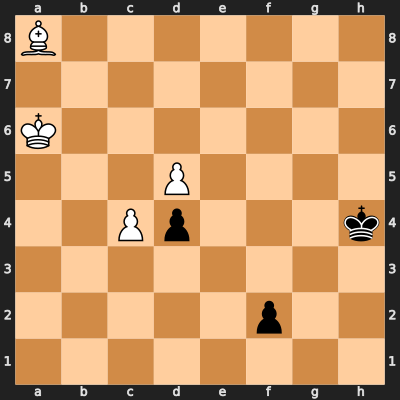

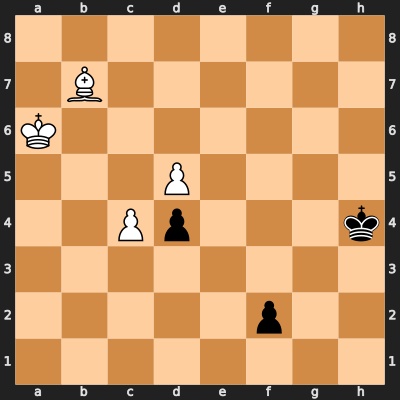

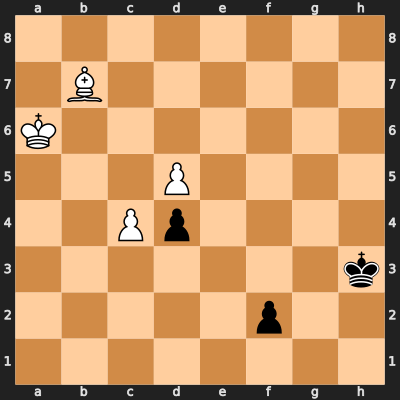

In [39]:
import chess
import chess.pgn
import chess.svg
from IPython.display import display, SVG

# Đường dẫn PGN
pgn_path = "./game_20251022_041446.pgn"

# Đọc ván cờ
with open(pgn_path, "r", encoding="utf-8") as f:
    game = chess.pgn.read_game(f)

board = game.board()

# Hiển thị từng nước
for move in game.mainline_moves():
    board.push(move)
    display(SVG(chess.svg.board(board=board, size=400)))


# Thuật toán A3C

In [7]:
import os, time, math, random
import numpy as np
import torch as th
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import torch.multiprocessing as mp

DEVICE = "cuda" if th.cuda.is_available() else "cpu"

def to_tensor_obs(obs_np: np.ndarray) -> th.Tensor:
    # (8,8,12) -> (1,12,8,8) float32
    x = th.from_numpy(obs_np).float().permute(2,0,1).unsqueeze(0)  # (1,12,8,8)
    return x

def apply_action_mask(logits: th.Tensor, mask_1d: np.ndarray) -> th.Tensor:
    """
    logits: (B, 4096) or (4096,)
    mask_1d: numpy vector of 0/1 length 4096
    """
    mask_t = th.from_numpy(mask_1d.astype(np.float32))
    if logits.dim() == 1:
        mask_t = mask_t.to(logits.device)
        masked = logits + (th.log(mask_t) if mask_t.min()>=1 else th.where(mask_t>0, th.zeros_like(logits), th.full_like(logits, -1e9)))
        return masked
    else:
        mask_t = mask_t.to(logits.device).unsqueeze(0)  # (1,4096)
        masked = logits + th.where(mask_t>0, th.zeros_like(logits), th.full_like(logits, -1e9))
        return masked

def sample_action(masked_logits: th.Tensor, deterministic: bool=False) -> (int, th.Tensor, th.Tensor):
    if masked_logits.dim() == 1:
        masked_logits = masked_logits.unsqueeze(0)
    dist = Categorical(logits=masked_logits)  # will softmax internally
    if deterministic:
        a = th.argmax(masked_logits, dim=-1)
    else:
        a = dist.sample()
    logp = dist.log_prob(a)
    ent = dist.entropy()
    return int(a.item()), logp.squeeze(0), ent.squeeze(0)


In [8]:
class ActorCriticNet(nn.Module):
    def __init__(self, features_dim=256, action_dim=64*64):
        super().__init__()
        C = 12
        self.cnn = nn.Sequential(
            nn.Conv2d(C, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        with th.no_grad():
            n_flat = self.cnn(th.zeros(1, C, 8, 8)).view(1,-1).shape[1]
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_flat, 512), nn.ReLU(),
            nn.Linear(512, features_dim), nn.ReLU(),
        )
        self.pi = nn.Linear(features_dim, action_dim)
        self.v  = nn.Linear(features_dim, 1)

    def forward(self, obs_1xCHW: th.Tensor):
        z = self.cnn(obs_1xCHW)
        h = self.fc(z)
        logits = self.pi(h)
        value  = self.v(h).squeeze(-1)  # (1,)
        return logits.squeeze(0), value.squeeze(0)


In [9]:
class SharedAdam(th.optim.Adam):
    # Adam với shared states cho A3C
    def __init__(self, params, lr=1e-4, **kwargs):
        super().__init__(params, lr=lr, **kwargs)
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state['step'] = th.zeros(1, dtype=th.long)
                state['exp_avg'] = th.zeros_like(p.data)
                state['exp_avg_sq'] = th.zeros_like(p.data)

                state['exp_avg'].share_memory_()
                state['exp_avg_sq'].share_memory_()
                state['step'].share_memory_()

def compute_returns(rewards, dones, last_value, gamma=0.99):
    R = last_value
    returns = []
    for r, d in zip(reversed(rewards), reversed(dones)):
        R = r + gamma * R * (1.0 - d)
        returns.append(R)
    returns.reverse()
    return returns

def worker_proc(rank, global_model, optimizer, cfg):
    th.set_num_threads(1)  # tránh tranh chấp CPU
    random.seed(cfg['seed'] + rank)
    np.random.seed(cfg['seed'] + rank)
    # env riêng cho worker
    env = ChessEnv()  # dùng RewardConfig mặc định; chỉnh nếu cần
    obs, info = env.reset(seed=cfg['seed'] + rank)

    local_model = ActorCriticNet().to(DEVICE)
    local_model.load_state_dict(global_model.state_dict())

    total_steps = 0
    while True:
        # Sync local <- global
        local_model.load_state_dict(global_model.state_dict())
        logps, values, rewards, dones, ents = [], [], [], [], []
        obs_list, act_list = [], []
        # rollout tối đa t_max bước (hoặc tới terminal)
        for t in range(cfg['t_max']):
            x = to_tensor_obs(obs).to(DEVICE)
            logits, value = local_model(x)
            masked_logits = apply_action_mask(logits, info['action_mask'].astype(np.float32))
            a, logp, ent = sample_action(masked_logits, deterministic=False)

            # thực thi
            obs_list.append(obs)
            act_list.append(a)
            logps.append(logp)
            values.append(value)
            ents.append(ent)

            obs, r, term, trunc, info = env.step(a)
            rewards.append(float(r))
            dones.append(float(term or trunc))

            total_steps += 1
            if term or trunc:
                obs, info = env.reset()
                break

        # bootstrap value
        with th.no_grad():
            x_next = to_tensor_obs(obs).to(DEVICE)
            _, next_v = local_model(x_next)
            next_v = next_v.detach()

        returns = compute_returns(rewards, dones, next_v.item(), gamma=cfg['gamma'])
        returns_t = th.tensor(returns, dtype=th.float32, device=DEVICE)
        values_t  = th.stack(values)
        logps_t   = th.stack(logps)
        ents_t    = th.stack(ents)

        adv = returns_t - values_t
        policy_loss = -(logps_t * adv.detach()).mean()
        value_loss  = 0.5 * adv.pow(2).mean()
        entropy_loss = -ents_t.mean()

        loss = policy_loss + cfg['vf_coef']*value_loss + cfg['ent_coef']*entropy_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(global_model.parameters(), cfg['max_grad_norm'])
        # apply grads to global
        for gp, lp in zip(global_model.parameters(), local_model.parameters()):
            if gp.grad is None and lp.grad is not None:
                gp.grad = lp.grad.clone()
        optimizer.step()

        if cfg['global_steps'].value >= cfg['max_global_steps']:
            break
        with cfg['lock']:
            cfg['global_steps'].value += len(rewards)
            gs = cfg['global_steps'].value
        if rank == 0 and gs % 10000 < cfg['t_max']:
            print(f"[A3C] global_steps={gs:,}  loss={loss.item():.3f}  "
                  f"pol={policy_loss.item():.3f} val={value_loss.item():.3f} ent={-entropy_loss.item():.3f}")
    # done


In [10]:
def run_a3c(num_workers=4, max_global_steps=200_000, seed=123):
    mp.set_start_method("spawn", force=True)

    global_model = ActorCriticNet().to(DEVICE)
    global_model.share_memory()
    optimizer = SharedAdam(global_model.parameters(), lr=1e-4)

    manager = mp.Manager()
    lock = manager.Lock()
    global_steps = manager.Value('i', 0)

    cfg = {
        't_max': 20,
        'gamma': 0.99,
        'vf_coef': 0.5,
        'ent_coef': 0.01,
        'max_grad_norm': 0.5,
        'seed': seed,
        'max_global_steps': max_global_steps,
        'global_steps': global_steps,
        'lock': lock,
    }

    procs = []
    for r in range(num_workers):
        p = mp.Process(target=worker_proc, args=(r, global_model, optimizer, cfg))
        p.daemon = True
        p.start()
        procs.append(p)

    for p in procs:
        p.join()

    return global_model

# chạy
a3c_model = run_a3c(num_workers=4, max_global_steps=100_000, seed=42)
th.save(a3c_model.state_dict(), "./a3c_chess.pt")
print("Saved ./a3c_chess.pt")


Saved ./a3c_chess.pt


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'worker_proc' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'worker_proc' on <module '__main__' (built-in)>
Traceback (most recent cal

In [ ]:
import chess

def a3c_policy_action(model: ActorCriticNet, env: ChessEnv, deterministic=False):
    obs = env._obs()
    x = to_tensor_obs(obs).to(DEVICE)
    logits, _ = model(x)
    mask = env._mask()
    masked_logits = apply_action_mask(logits.squeeze(0), mask.astype(np.float32))
    a, _, _ = sample_action(masked_logits, deterministic=deterministic)
    return a

class RandomLegalOpponent:
    def select(self, env):
        mask = env._mask()
        legal = np.flatnonzero(mask==1)
        return int(np.random.choice(legal)) if legal.size else 0

def play_game_a3c(model, as_white=True, max_moves=300, deterministic=False, show=False):
    env = ChessEnv()
    obs, info = env.reset()
    opp = RandomLegalOpponent()
    total_r = 0.0
    agent_moved_last = False

    for ply in range(max_moves):
        agents_turn = (env.board.turn and as_white) or ((not env.board.turn) and (not as_white))
        if agents_turn:
            a = a3c_policy_action(model, env, deterministic)
            mv = chess.Move(a//64, a%64)
            move_san = env.board.san(mv)
            agent_moved_last = True
        else:
            a = opp.select(env)
            mv = chess.Move(a//64, a%64)
            move_san = env.board.san(mv)
            agent_moved_last = False

        _, r, term, trunc, _ = env.step(int(a))
        total_r += float(r)
        if show:
            who = "Trắng" if not env.board.turn else "Đen"
            print(f"Ply {ply+1}: {who} đi {move_san}")
            print(env.board.unicode())

        if term or trunc:
            break

    # kết quả
    if env.board.is_checkmate():
        res = 1 if agent_moved_last else -1
    elif (env.board.is_stalemate() or env.board.is_insufficient_material()
          or env.board.is_seventyfive_moves() or env.board.is_fivefold_repetition()
          or env.board.can_claim_fifty_moves() or env.board.can_claim_threefold_repetition()):
        res = 0
    else:
        res = 0
    return res, total_r, len(env.board.move_stack)

# demo 10 ván
wins=draws=losses=0
for i in range(10):
    res, tot, ply = play_game_a3c(a3c_model, as_white=(i%2==0), deterministic=False, max_moves=200, show=False)
    if res==1: wins+=1
    elif res==0: draws+=1
    else: losses+=1
print(f"A3C vs random (10 games) W/D/L = {wins}/{draws}/{losses}")


_____________________________________________________________________________________________________

In [2]:
import chess
board = chess.Board()
print(board.unicode())

♜ ♞ ♝ ♛ ♚ ♝ ♞ ♜
♟ ♟ ♟ ♟ ♟ ♟ ♟ ♟
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
♙ ♙ ♙ ♙ ♙ ♙ ♙ ♙
♖ ♘ ♗ ♕ ♔ ♗ ♘ ♖


In [3]:
def print_bitboard(bitboard):
    
    # for each row
    for i in range(8):
        
        # print bitboard of 1s/0s (we have to mirror the bitboard)
        if i == 0:
            print(format(bitboard, "064b")[8*(i+1)-1::-1])
        else:
            print(format(bitboard, "064b")[8*(i+1)-1:8*i-1:-1])

# bitboard of pawns
print_bitboard(board.pawns)

00000000
11111111
00000000
00000000
00000000
00000000
11111111
00000000


In [4]:
# bitboard of kings
print_bitboard(board.kings)

00001000
00000000
00000000
00000000
00000000
00000000
00000000
00001000


In [5]:
import numpy as np

def encode_valid_moves(board):
    
    valid_moves_dict = {}
    
    # for each valid move
    for move in board.legal_moves:
        
        # compute index based on starting square and target square
        index = 64 * (move.from_square) + (move.to_square)
        valid_moves_dict[index] = move
    
    return valid_moves_dict

valid_moves_dict = encode_valid_moves(board)
valid_moves_dict

{407: Move.from_uci('g1h3'),
 405: Move.from_uci('g1f3'),
 82: Move.from_uci('b1c3'),
 80: Move.from_uci('b1a3'),
 983: Move.from_uci('h2h3'),
 918: Move.from_uci('g2g3'),
 853: Move.from_uci('f2f3'),
 788: Move.from_uci('e2e3'),
 723: Move.from_uci('d2d3'),
 658: Move.from_uci('c2c3'),
 593: Move.from_uci('b2b3'),
 528: Move.from_uci('a2a3'),
 991: Move.from_uci('h2h4'),
 926: Move.from_uci('g2g4'),
 861: Move.from_uci('f2f4'),
 796: Move.from_uci('e2e4'),
 731: Move.from_uci('d2d4'),
 666: Move.from_uci('c2c4'),
 601: Move.from_uci('b2b4'),
 536: Move.from_uci('a2a4')}

In [6]:
def mask_and_valid_moves(board):

    mask = np.zeros((64, 64))
    valid_moves_dict = {}
    
    # for each valid move
    for move in board.legal_moves:
        
        # mask is a matrix
        mask[move.from_square, move.to_square] = 1
        
        # compute index based on starting square and target square
        index = 64 * (move.from_square) + (move.to_square)
        
        valid_moves_dict[index] = move
    
    return mask, valid_moves_dict

mask, valid_moves_dict = mask_and_valid_moves(board)
mask

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])